<a href="https://colab.research.google.com/github/mistysaha/Water_Management_Dashboard/blob/main/Water_Purification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**-----------------------------------------------OBJECTIVE 1----------------------------------------------**

Develop an AI-driven system for real time monitoring and controlling of water purification

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Indian_water_data.csv to Indian_water_data.csv


In [2]:
import pandas as pd

In [3]:
df= pd.read_csv('Indian_water_data.csv')
df.head(5)


,STN code,Monitoring Location,Year,Type Water Body,State Name,Temperature (C) - Min,Temperature (C) - Max,Dissolved - Min,Dissolved - Max,pH - Min,...,BOD (mg/L) - Min,BOD (mg/L) - Max,NitrateN (mg/L) - Min,NitrateN (mg/L) - Max,Fecal Coliform (MPN/100ml) - Min,Fecal Coliform (MPN/100ml) - Max,Total Coliform (MPN/100ml) - Min,Total Coliform (MPN/100ml) - Max,Fecal - Min,Fecal - Max
0,4085,"RIVER JUMAR AT BIT MESRA, RANCHI",2022,RIVER,JHARKHAND,12.0,29.0,3.3,5.2,6.5,...,2,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2396,RIVER JUMAR AT KANKE DAM,2022,RIVER,JHARKHAND,12.0,26.0,5.9,7.2,7.5,...,1.9,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2401,RIVER AJAY AT MASANJORE DAM,2022,RIVER,JHARKHAND,17.0,36.0,5.8,6.6,7.5,...,1.3,1.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3554,"RIVER KONAR NEAR SWANG COAL WASHERY, BOKARO",2022,RIVER,JHARKHAND,19.0,34.0,7.4,7.8,7.3,...,1.8,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2390,RIVER KONAR AT TENUGHAT DAM,2022,RIVER,JHARKHAND,16.0,33.0,7.4,8.0,7.4,...,1.3,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail(5)

,STN code,Monitoring Location,Year,Type Water Body,State Name,Temperature (C) - Min,Temperature (C) - Max,Dissolved - Min,Dissolved - Max,pH - Min,...,BOD (mg/L) - Min,BOD (mg/L) - Max,NitrateN (mg/L) - Min,NitrateN (mg/L) - Max,Fecal Coliform (MPN/100ml) - Min,Fecal Coliform (MPN/100ml) - Max,Total Coliform (MPN/100ml) - Min,Total Coliform (MPN/100ml) - Max,Fecal - Min,Fecal - Max
189,20046,MADURAI,2023,STP,TAMIL NADU,25.0,39.0,0.3,6.0,6.7,...,4,18.0,0.3,1.0,2,11000,2,22000.0,2,NaN
190,3054,RIVER GODAVARI - OUTLET OF ASH POND EFFLUENTS ...,2023,DRAIN,TELANGANA,25.0,29.0,1.6,6.0,8.5,...,1,5.4,0.9,3.8,2,17,17,280.0,2,NaN
191,4665,RIVER MANERU (TRIBUTARY OF GODAVARI) - OUTLET ...,2023,DRAIN,TELANGANA,25.0,28.0,2.8,6.1,7.5,...,1.8,3.2,0.4,17.0,2,2,26,58.0,2,NaN
192,3055,"AMBERPET STP (339 MLD) - OUTLET , AMBERPET (V&...",2023,STP,TELANGANA,25.0,31.0,0.9,4.6,6.9,...,4.4,30.0,4.2,8.0,4,46,220,920.0,2,NaN
193,3050,WATER WORKS- GHAZIABAD,2023,WATER TREATMENT PLANT (RAW WATER),UTTAR PRADESH,18.0,26.0,0.3,11.0,7.1,...,1,1.0,0.3,0.3,2,2,2,2.0,2,NaN


In [5]:
print(df.shape)

(194, 23)


In [6]:
print(df.isnull().sum())

STN code                              0
Monitoring Location                   0
Year                                  0
Type Water Body                       0
State Name                            0
Temperature (C) - Min                 2
Temperature (C) - Max                 2
Dissolved - Min                       1
Dissolved - Max                       1
pH - Min                              0
pH - Max                              0
Conductivity (¬µmho/cm) - Min        13
Conductivity (¬µmho/cm) - Max        13
BOD (mg/L) - Min                     13
BOD (mg/L) - Max                     15
NitrateN (mg/L) - Min                13
NitrateN (mg/L) - Max                13
Fecal Coliform (MPN/100ml) - Min     13
Fecal Coliform (MPN/100ml) - Max     13
Total Coliform (MPN/100ml) - Min     14
Total Coliform (MPN/100ml) - Max     15
Fecal - Min                          62
Fecal - Max                         102
dtype: int64


In [7]:
print(df.dtypes)

STN code                              int64
Monitoring Location                  object
Year                                  int64
Type Water Body                      object
State Name                           object
Temperature (C) - Min               float64
Temperature (C) - Max               float64
Dissolved - Min                      object
Dissolved - Max                     float64
pH - Min                            float64
pH - Max                            float64
Conductivity (¬µmho/cm) - Min        object
Conductivity (¬µmho/cm) - Max       float64
BOD (mg/L) - Min                     object
BOD (mg/L) - Max                    float64
NitrateN (mg/L) - Min                object
NitrateN (mg/L) - Max               float64
Fecal Coliform (MPN/100ml) - Min     object
Fecal Coliform (MPN/100ml) - Max     object
Total Coliform (MPN/100ml) - Min     object
Total Coliform (MPN/100ml) - Max    float64
Fecal - Min                          object
Fecal - Max                     

In [8]:
#handling missing values by filling with median
df = df.fillna(df.median(numeric_only=True))

In [9]:
df = df.drop_duplicates()

In [10]:
print(df.describe())

           STN code         Year  Temperature (C) - Min  \
count    194.000000   194.000000             194.000000   
mean    4122.922680  2022.273196              18.444845   
std     4101.028601     0.809659               6.720481   
min     1013.000000  2021.000000               1.000000   
25%     2354.000000  2022.000000              13.250000   
50%     3875.500000  2022.500000              21.000000   
75%     4377.000000  2023.000000              23.000000   
max    30080.000000  2023.000000              28.000000   

       Temperature (C) - Max  Dissolved - Max    pH - Min    pH - Max  \
count             194.000000       194.000000  194.000000  194.000000   
mean               27.472165         7.656186    7.125464    8.003351   
std                 6.556692         1.803965    0.446252    0.460290   
min                 8.000000         1.100000    5.700000    6.600000   
25%                24.250000         6.700000    6.800000    7.700000   
50%                29.000000  

In [11]:
#save cleaned csv
df.to_csv('cleaned_water_quality.csv', index=False)

In [12]:
print(df.nlargest(3, 'Conductivity (¬µmho/cm) - Max'))
print(df.nlargest(3, 'Total Coliform (MPN/100ml) - Max'))

     STN code Monitoring Location  Year Type Water Body State Name  \
123      4013       TIRACOL BEACH  2021           BEACH        GOA   
125      4015     CALANGUTE BEACH  2021           BEACH        GOA   
126      4016        MORJIM BEACH  2021           BEACH        GOA   

     Temperature (C) - Min  Temperature (C) - Max Dissolved - Min  \
123                   27.0                   31.0             6.4   
125                   27.0                   30.0             6.1   
126                   28.0                   31.0               6   

     Dissolved - Max  pH - Min  ...  BOD (mg/L) - Min BOD (mg/L) - Max  \
123              7.7       7.6  ...               BDL              1.9   
125              7.0       6.5  ...               1.1              1.9   
126              7.7       7.7  ...               BDL              1.9   

     NitrateN (mg/L) - Min NitrateN (mg/L) - Max  \
123                    0.3                   0.5   
125                    0.3               

In [13]:
import pandas as pd

#converting cols to numeric
df['Fecal Coliform (MPN/100ml) - Max'] = pd.to_numeric(df['Fecal Coliform (MPN/100ml) - Max'], errors='coerce')
df['Dissolved - Min'] = pd.to_numeric(df['Dissolved - Min'], errors='coerce')

#filling nan values
#using the median of their respective columns
df['Fecal Coliform (MPN/100ml) - Max'] = df['Fecal Coliform (MPN/100ml) - Max'].fillna(df['Fecal Coliform (MPN/100ml) - Max'].median())
df['Dissolved - Min'] = df['Dissolved - Min'].fillna(df['Dissolved - Min'].median())

def label_quality(row):
    if (row['Fecal Coliform (MPN/100ml) - Max'] <= 500 and
        6.5 <= row['pH - Min'] and row['pH - Max'] <= 8.5 and
        row['Dissolved - Min'] >= 5 and
        row['BOD (mg/L) - Max'] <= 3):
        return 'Good'
    else:
        return 'Poor'

df['Water_Quality_Label'] = df.apply(label_quality, axis=1)
print(df['Water_Quality_Label'].value_counts())

Water_Quality_Label
Poor    103
Good     91
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#stripping white spaces
df.columns = df.columns.str.strip()

X = df.drop(['Water_Quality_Label', 'STN code', 'Monitoring Location', 'State Name'], axis=1)
X = X.select_dtypes(include='number') #keeping only numeric columns
y = df['Water_Quality_Label']

#80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#train random forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#test
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

        Good       0.94      0.89      0.92        19
        Poor       0.90      0.95      0.93        20

    accuracy                           0.92        39
   macro avg       0.92      0.92      0.92        39
weighted avg       0.92      0.92      0.92        39



In [15]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.3 MB/s eta 0:00:00


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   STN code                          194 non-null    int64  
 1   Monitoring Location               194 non-null    object 
 2   Year                              194 non-null    int64  
 3   Type Water Body                   194 non-null    object 
 4   State Name                        194 non-null    object 
 5   Temperature (C) - Min             194 non-null    float64
 6   Temperature (C) - Max             194 non-null    float64
 7   Dissolved - Min                   194 non-null    float64
 8   Dissolved - Max                   194 non-null    float64
 9   pH - Min                          194 non-null    float64
 10  pH - Max                          194 non-null    float64
 11  Conductivity (¬µmho/cm) - Min     181 non-null    object 
 12  Conducti

In [17]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

#Getting real percentile boundaries
c25, c50, c75 = df['Conductivity (¬µmho/cm) - Max'].quantile([0.25, 0.5, 0.75])
b25, b50, b75 = df['BOD (mg/L) - Max'].quantile([0.25, 0.5, 0.75])

conductivity = ctrl.Antecedent(np.arange(4, 62000, 100), 'conductivity')
bod = ctrl.Antecedent(np.arange(1, 91, 1), 'bod')
dosage = ctrl.Consequent(np.arange(0, 51, 1), 'dosage')

conductivity['low'] = fuzz.trimf(conductivity.universe, [4, 4, c50])
conductivity['medium'] = fuzz.trimf(conductivity.universe, [c25, c50, c75])
conductivity['high'] = fuzz.trimf(conductivity.universe, [c50, 62000, 62000])

bod['low'] = fuzz.trimf(bod.universe, [1, 1, b50])
bod['medium'] = fuzz.trimf(bod.universe, [b25, b50, b75])
bod['high'] = fuzz.trimf(bod.universe, [b50, 90, 90])

dosage['low'] = fuzz.trimf(dosage.universe, [0, 0, 20])
dosage['medium'] = fuzz.trimf(dosage.universe, [10, 25, 40])
dosage['high'] = fuzz.trimf(dosage.universe, [30, 50, 50])

rule1 = ctrl.Rule(conductivity['high'] | bod['high'], dosage['high'])
rule2 = ctrl.Rule(conductivity['medium'] & bod['medium'], dosage['medium'])
rule3 = ctrl.Rule(conductivity['low'] & bod['low'], dosage['low'])
rule4 = ctrl.Rule(conductivity['medium'] & bod['low'], dosage['medium'])
rule5 = ctrl.Rule(conductivity['low'] & bod['medium'], dosage['medium'])

dosage_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])

recommended_dosages = []
for i, row in df.iterrows():
    sim = ctrl.ControlSystemSimulation(dosage_ctrl)
    sim.input['conductivity'] = row['Conductivity (¬µmho/cm) - Max']
    sim.input['bod'] = row['BOD (mg/L) - Max']
    sim.compute()
    try:
        recommended_dosages.append(sim.output['dosage'])
    except KeyError:
        recommended_dosages.append(None)

df['Recommended_Coagulant_Dosage'] = recommended_dosages
print(df[['Monitoring Location', 'Water_Quality_Label', 'Recommended_Coagulant_Dosage']].head(10))

                           Monitoring Location Water_Quality_Label  \
0             RIVER JUMAR AT BIT MESRA, RANCHI                Poor   
1                     RIVER JUMAR AT KANKE DAM                Poor   
2                  RIVER AJAY AT MASANJORE DAM                Good   
3  RIVER KONAR NEAR SWANG COAL WASHERY, BOKARO                Good   
4                  RIVER KONAR AT TENUGHAT DAM                Good   
5             RIVER GARGA NEAR TELMUCHO BRIDGE                Poor   
6             RIVER BOKARO AT ZARANGDIH BRIDGE                Good   
7              RIVER SANKH AT BOLBA, JHARKHAND                Good   
8                 RIVER BARAKAR AT MAITHAN DAM                Good   
9  RIVER DAMODAR NEAR ZARANGDIH BRIDGE, BOKARO                Good   

   Recommended_Coagulant_Dosage  
0                     21.721211  
1                     40.034286  
2                     14.498610  
3                     23.592250  
4                     24.413110  
5                     40.

/tmp/ipykernel_435/1506427569.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Water_Quality_Label', data=df, palette=["#F48FB1", "#C2185B"])


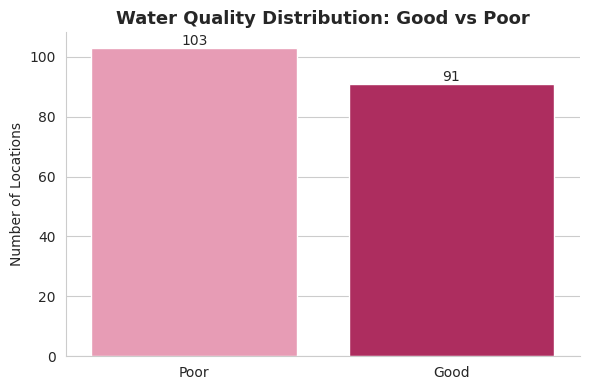

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
pink_palette = ["#F8BBD0", "#F48FB1", "#EC407A", "#C2185B", "#880E4F"]

# Chart 1: Good vs Poor count
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Water_Quality_Label', data=df, palette=["#F48FB1", "#C2185B"])
plt.title('Water Quality Distribution: Good vs Poor', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Locations')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


/tmp/ipykernel_435/2589161559.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Water_Quality_Label', y='Recommended_Coagulant_Dosage', data=df,


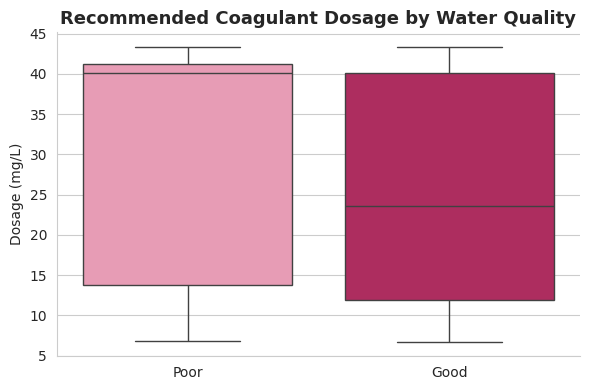

In [19]:

#Chart 2: Dosage by water quality
plt.figure(figsize=(6,4))
sns.boxplot(x='Water_Quality_Label', y='Recommended_Coagulant_Dosage', data=df,
            palette=["#F48FB1", "#C2185B"])
plt.title('Recommended Coagulant Dosage by Water Quality', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Dosage (mg/L)')
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


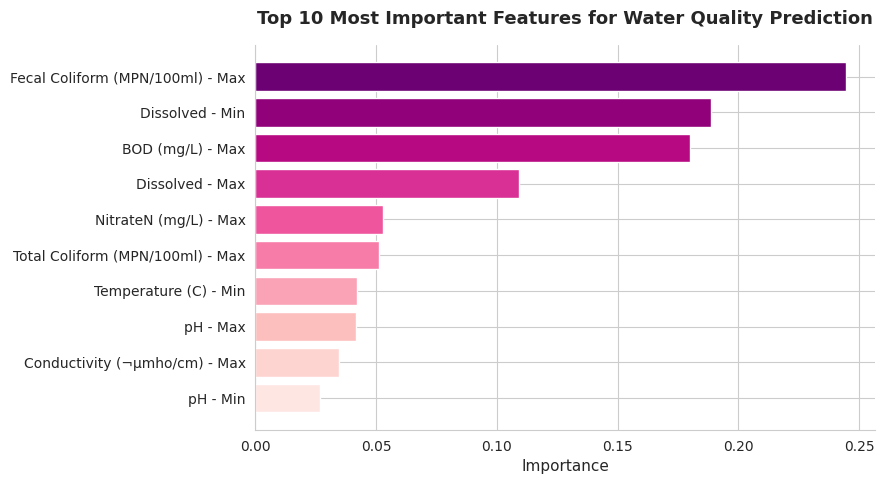

In [20]:
# Chart 3: Feature importance
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False).head(10)
plt.figure(figsize=(8,5))
colors = sns.color_palette("RdPu", len(feat_df))[::-1]
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color=colors[::-1])
plt.xlabel('Importance', fontsize=11)
plt.title('Top 10 Most Important Features for Water Quality Prediction', fontsize=13, fontweight='bold', pad=15)
plt.gca().spines[['top','right']].set_visible(False)

**---------------------------------------------------
OBJECTIVE 2--------------------------------------------------------------**
Design and implement AI algorithms for automatic leakqage detection and prediction

In [21]:

#creating simulated dataset

import numpy as np
import pandas as pd



In [22]:
np.random.seed(42)

n_samples = 1000
n_leak = int(n_samples * 0.2)   # ~20% of readings represent leak events
n_normal = n_samples - n_leak

# Normal readings
normal_pressure = np.random.normal(loc=50, scale=5, size=n_normal)      # steady pressure ~50 psi
normal_flow = np.random.normal(loc=100, scale=10, size=n_normal)        # steady flow ~100 L/min
normal_vibration = np.random.normal(loc=2, scale=0.5, size=n_normal)    # low vibration

#Leak readings (pressure drops, flow becomes abnormal, vibration rises)
leak_pressure = np.random.normal(loc=30, scale=8, size=n_leak)          # noticeably lower pressure
leak_flow = np.random.normal(loc=130, scale=20, size=n_leak)            # higher/erratic flow
leak_vibration = np.random.normal(loc=5, scale=1.2, size=n_leak)        # higher vibration

#Combine into one dataframe
pressure = np.concatenate([normal_pressure, leak_pressure])
flow = np.concatenate([normal_flow, leak_flow])
vibration = np.concatenate([normal_vibration, leak_vibration])
label = ['No Leak'] * n_normal + ['Leak'] * n_leak

leak_df = pd.DataFrame({
    'Pressure_psi': pressure,
    'Flow_Lmin': flow,
    'Vibration': vibration,
    'Leak_Label': label
})

# Shuffle rows so leaks aren't all bunched at the end
leak_df = leak_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [23]:
# adding states
import numpy as np
np.random.seed(2)

states_list = df['State Name'].unique()  # reuse the same states from your water quality data
leak_df['State Name'] = np.random.choice(states_list, size=len(leak_df))


In [24]:
print(leak_df.shape)
print(leak_df['Leak_Label'].value_counts())
leak_df.head(10)

(1000, 5)
Leak_Label
No Leak    800
Leak       200
Name: count, dtype: int64


,Pressure_psi,Flow_Lmin,Vibration,Leak_Label,State Name
0,52.716801,105.296928,2.392302,No Leak,GUJARAT
1,54.913455,94.672992,2.024887,No Leak,TELANGANA
2,40.795629,99.724851,2.349414,No Leak,ODISHA
3,47.131690,98.615440,2.218369,No Leak,GUJARAT
4,44.376790,93.070948,1.618638,No Leak,HARYANA
5,54.678392,91.125078,2.333156,No Leak,HARYANA
6,45.051976,120.562071,2.709802,No Leak,GUJARAT
7,45.462182,105.578103,1.498906,No Leak,DELHI
8,33.776018,141.065024,5.232929,Leak,UTTARAKHAND
9,46.083734,89.787672,1.473159,No Leak,HARYANA


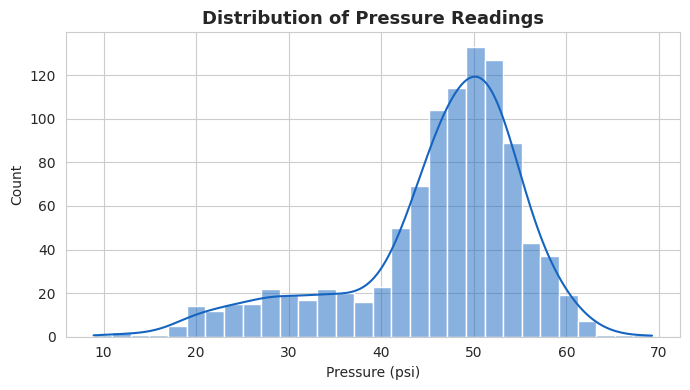

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------- Chart 1: Distribution of Pressure ----------
plt.figure(figsize=(7,4))
sns.histplot(leak_df['Pressure_psi'], bins=30, color='#1565C0', kde=True)
plt.title('Distribution of Pressure Readings', fontsize=13, fontweight='bold')
plt.xlabel('Pressure (psi)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



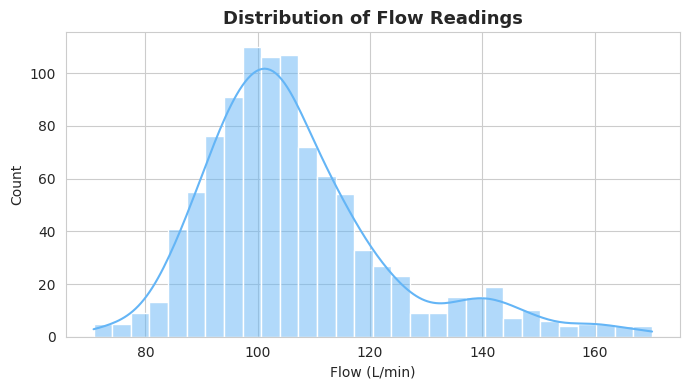

In [26]:
# ---------- Chart 2: Distribution of Flow ----------
plt.figure(figsize=(7,4))
sns.histplot(leak_df['Flow_Lmin'], bins=30, color='#64B5F6', kde=True)
plt.title('Distribution of Flow Readings', fontsize=13, fontweight='bold')
plt.xlabel('Flow (L/min)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



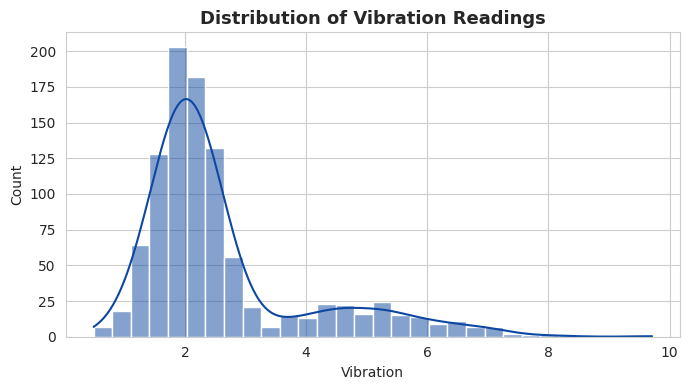

In [27]:
# ---------- Chart 3: Distribution of Vibration ----------
plt.figure(figsize=(7,4))
sns.histplot(leak_df['Vibration'], bins=30, color='#0D47A1', kde=True)
plt.title('Distribution of Vibration Readings', fontsize=13, fontweight='bold')
plt.xlabel('Vibration')
plt.ylabel('Count')
plt.tight_layout()
plt.show()




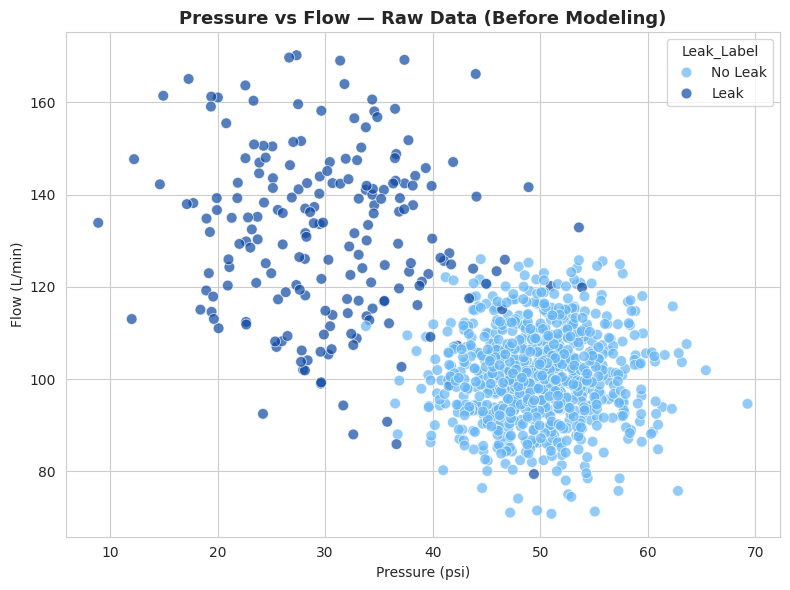

In [28]:
# ---------- Chart 4: Pressure vs Flow, colored by known Leak_Label ----------
plt.figure(figsize=(8,6))
sns.scatterplot(data=leak_df, x='Pressure_psi', y='Flow_Lmin', hue='Leak_Label',
                 palette={'No Leak': '#64B5F6', 'Leak': '#0D47A1'}, s=60, alpha=0.7)
plt.title('Pressure vs Flow — Raw Data (Before Modeling)', fontsize=13, fontweight='bold')
plt.xlabel('Pressure (psi)')
plt.ylabel('Flow (L/min)')
plt.tight_layout()
plt.show()



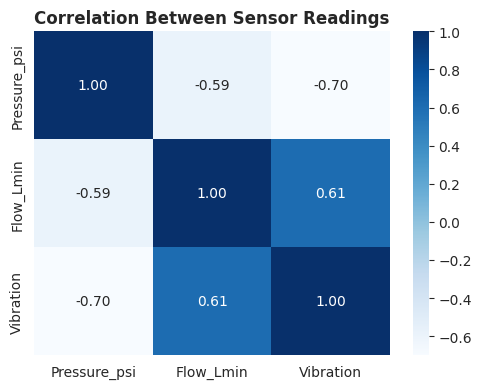

In [29]:
# ---------- Chart 5: Correlation heatmap between the 3 sensor readings ----------
plt.figure(figsize=(5,4))
corr = leak_df[['Pressure_psi', 'Flow_Lmin', 'Vibration']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Between Sensor Readings', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [30]:
#training random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = leak_df[['Pressure_psi', 'Flow_Lmin', 'Vibration']]
y = leak_df['Leak_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

leak_model = RandomForestClassifier(n_estimators=100, random_state=42)
leak_model.fit(X_train, y_train)

y_pred = leak_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.995
              precision    recall  f1-score   support

        Leak       1.00      0.97      0.99        40
     No Leak       0.99      1.00      1.00       160

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [31]:
#anomaly detection

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.2, random_state=42)
leak_df['Anomaly_Score'] = iso_model.fit_predict(leak_df[['Pressure_psi', 'Flow_Lmin', 'Vibration']])

#-1 = anomaly(unusual),1 =normal
leak_df['Anomaly_Label'] = leak_df['Anomaly_Score'].map({1: 'Normal', -1: 'Anomaly'})

print(leak_df['Anomaly_Label'].value_counts())
print(pd.crosstab(leak_df['Leak_Label'], leak_df['Anomaly_Label']))

Anomaly_Label
Normal     800
Anomaly    200
Name: count, dtype: int64
Anomaly_Label  Anomaly  Normal
Leak_Label                    
Leak               172      28
No Leak             28     772


In [32]:
#putting early warning label

#random forest prediction
leak_df['RF_Prediction'] = leak_model.predict(leak_df[['Pressure_psi', 'Flow_Lmin', 'Vibration']])

# Combine RF prediction + Anomaly detection into a Risk Level
def get_risk_level(row):
    rf_says_leak = row['RF_Prediction'] == 'Leak'
    anomaly_flag = row['Anomaly_Label'] == 'Anomaly'

    if rf_says_leak and anomaly_flag:
        return 'High Risk'
    elif rf_says_leak or anomaly_flag:
        return 'Medium Risk'
    else:
        return 'Low Risk'

leak_df['Risk_Level'] = leak_df.apply(get_risk_level, axis=1)

print(leak_df['Risk_Level'].value_counts())

Risk_Level
Low Risk       773
High Risk      172
Medium Risk     55
Name: count, dtype: int64


/tmp/ipykernel_435/1783862519.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Risk_Level', data=leak_df, order=risk_order,


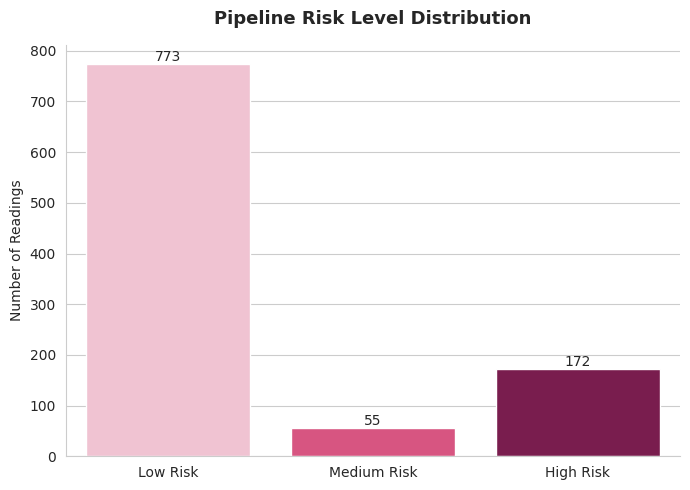

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

#chart1: Risk Level

sns.set_style("whitegrid")

risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
risk_colors = {'Low Risk': '#F8BBD0', 'Medium Risk': '#EC407A', 'High Risk': '#880E4F'}

plt.figure(figsize=(7,5))
ax = sns.countplot(x='Risk_Level', data=leak_df, order=risk_order,
                    palette=[risk_colors[r] for r in risk_order])
plt.title('Pipeline Risk Level Distribution', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('Number of Readings')
for container in ax.containers:
    ax.bar_label(container, fontsize=10)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

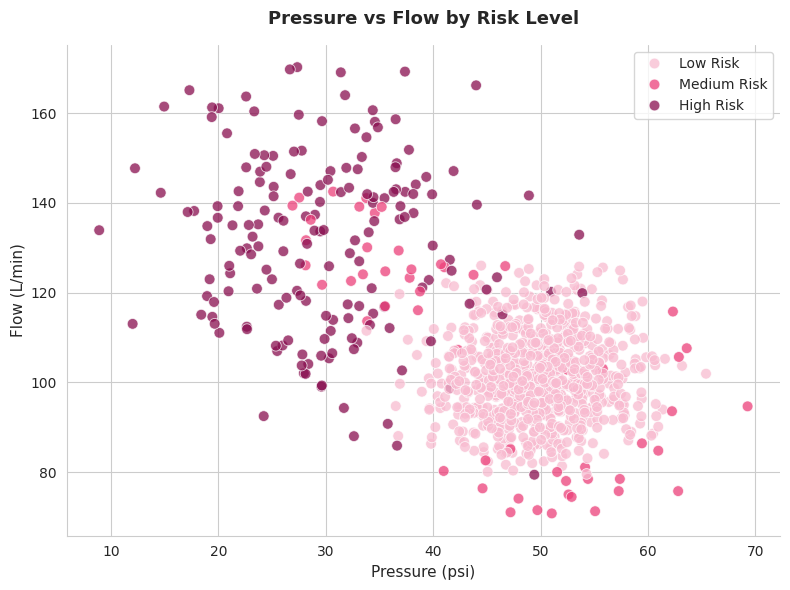

In [34]:
#chart 2: risk in pressure and flow

plt.figure(figsize=(8,6))
sns.scatterplot(data=leak_df, x='Pressure_psi', y='Flow_Lmin', hue='Risk_Level',
                 hue_order=risk_order,
                 palette=risk_colors, s=60, alpha=0.75)
plt.title('Pressure vs Flow by Risk Level', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Pressure (psi)', fontsize=11)
plt.ylabel('Flow (L/min)', fontsize=11)
plt.gca().spines[['top','right']].set_visible(False)
plt.legend(title='')
plt.tight_layout()
plt.show()

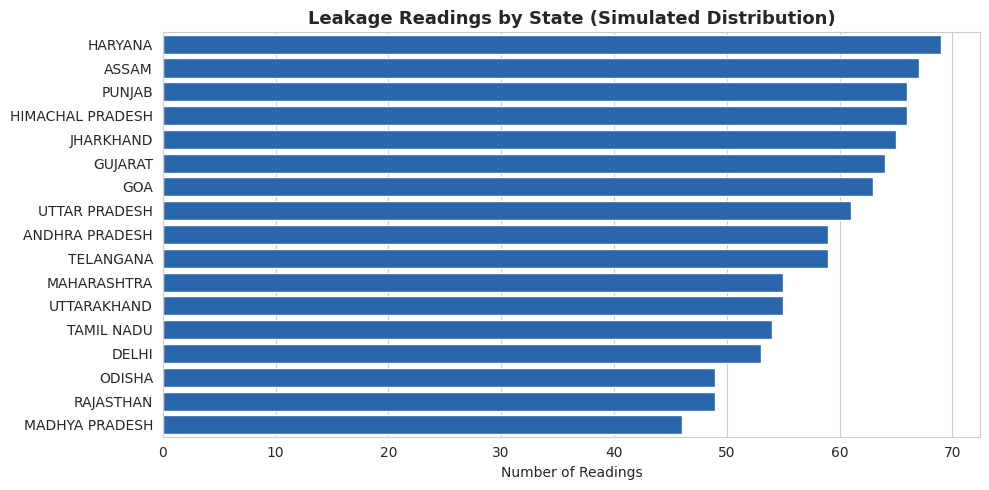

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(y='State Name', data=leak_df, order=leak_df['State Name'].value_counts().index, color='#1565C0')
plt.title('Leakage Readings by State (Simulated Distribution)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Readings')
plt.ylabel('')
plt.tight_layout()
plt.show()

**-----------------------------------------------OBJECTIVE 3 ----------------------------------------------**

make dashboard

In [36]:
# adding latitudes and longitudes to state for map
state_coords = {
    'JHARKHAND': (23.6102, 85.2799),
    'HIMACHAL PRADESH': (31.1048, 77.1734),
    'UTTARAKHAND': (30.0668, 79.0193),
    'MADHYA PRADESH': (22.9734, 78.6569),
    'RAJASTHAN': (27.0238, 74.2179),
    'ANDHRA PRADESH': (15.9129, 79.7400),
    'GOA': (15.2993, 74.1240),
    'DELHI': (28.7041, 77.1025),
    'GUJARAT': (22.2587, 71.1924),
    'ASSAM': (26.2006, 92.9376),
    'PUNJAB': (31.1471, 75.3412),
    'HARYANA': (29.0588, 76.0856),
    'MAHARASHTRA': (19.7515, 75.7139),
    'ODISHA': (20.9517, 85.0985),
    'TAMIL NADU': (11.1271, 78.6569),
    'TELANGANA': (18.1124, 79.0193),
    'UTTAR PRADESH': (26.8467, 80.9462)
}

df['Latitude'] = df['State Name'].map(lambda x: state_coords.get(x, (22.0, 79.0))[0])
df['Longitude'] = df['State Name'].map(lambda x: state_coords.get(x, (22.0, 79.0))[1])

# Add small random spread so multiple locations in the same state don't overlap
import numpy as np
np.random.seed(1)
df['Latitude'] = df['Latitude'] + np.random.uniform(-0.4, 0.4, len(df))
df['Longitude'] = df['Longitude'] + np.random.uniform(-0.4, 0.4, len(df))

In [37]:
# Export the water quality dataframe (Objective 1 results)
df.to_csv('water_quality_results.csv', index=False)

# Export the leakage dataframe (Objective 2 results)
leak_df.to_csv('leakage_results.csv', index=False)

from google.colab import files
files.download('water_quality_results.csv')
files.download('leakage_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>